In [ ]:
!pip install swig
!pip install gymnasium[box2d]

  Using cached swig-4.3.1-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (3.5 kB)
Using cached swig-4.3.1-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.9 MB)
  Using cached box2d-py-2.3.5.tar.gz (374 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for box2d-py: filename=box2d_py-2.3.5-cp311-cp311-linux_x86_64.whl size=2379365 sha256=6e38f93d7edbc8604bd99cf7ddd9060a9d1a47980dc7b58f0cad0f631361dd63
  Stored in directory: /root/.cache/pip/wheels/ab/f1/0c/d56f4a2bdd12bae0a0693ec33f2f0daadb5eb9753c78fa5308
Successfully built box2d-py




# 🌌 LunarLander-v2: Entorno y Objetivo

## 🎮 Descripción del entorno

* **Nombre:** `LunarLander-v3`
* **Tipo:** Entorno clásico de control continuo con acciones discretas.
* **Simulación:** Una nave espacial debe aterrizar suavemente en una superficie lunar entre dos banderas.
* **Estado (observación):** Vector de **8 variables continuas** que describen la situación del módulo:

  1. `x` → posición horizontal
  2. `y` → posición vertical
  3. `vx` → velocidad horizontal
  4. `vy` → velocidad vertical
  5. `angle` → ángulo de inclinación
  6. `vangle` → velocidad angular
  7. `left_leg_contact` → indicador binario (1 si la pata izquierda toca el suelo)
  8. `right_leg_contact` → indicador binario (1 si la pata derecha toca el suelo)

En resumen: el estado es una **fotografía física** de la nave en cada instante.

---

## 🎯 Espacio de acciones

El agente puede elegir entre **4 acciones discretas**:

* `0`: no hacer nada
* `1`: encender motor izquierdo (empuja hacia la derecha)
* `2`: encender motor principal (empuja hacia arriba)
* `3`: encender motor derecho (empuja hacia la izquierda)

Estas acciones son la única manera de controlar la caída y orientación del módulo.

---

## 💰 Recompensas

* Aterrizar suavemente entre las banderas: **+100 a +140**
* Chocar o salir de la zona: **-100**
* Encender motores: costo proporcional (penaliza gasto de combustible)
* Cada paso estable dentro de la zona de aterrizaje: pequeñas recompensas positivas

👉 Esto significa que el agente debe **equilibrar** llegar al suelo de forma estable con **minimizar el uso de combustible**.

---

## 🧠 Objetivo de aprendizaje

El **agente de RL** busca **maximizar la recompensa acumulada** en cada episodio.
En otras palabras:

* Aprender a **aterrizar en la zona segura**
* Hacerlo de forma **estable** (controlando ángulo y velocidad)
* Usando **la menor cantidad de combustible posible**

---

## 🚀 Nota sobre la discretización

El estado original es **continuo** (infinitas posibilidades). Para usar **Q-Learning tabular**, lo transformamos en un estado **discreto** mediante **bins**.
Ejemplo:

* Posición `x` en `[-1.5, 1.5]` → 7 intervalos
* Velocidad `vx` en `[-2.0, 2.0]` → 7 intervalos

Así, cada estado continuo se convierte en una **tupla de enteros**, y podemos aplicar Q-Learning con una tabla `Q[s][a]`.

---



In [ ]:
# --- Librerías base y utilidades ---
import os, shutil, random, math
from collections import defaultdict
from typing import Tuple

import numpy as np
import matplotlib.pyplot as plt

# Gymnasium (la versión moderna de OpenAI Gym)
import gymnasium as gym
from gymnasium.wrappers import RecordVideo

# Para mostrar videos dentro del notebook (Jupyter)
from IPython.display import Video, display

# Reproducibilidad
RNG_SEED = 42
np.random.seed(RNG_SEED)
random.seed(RNG_SEED)

# Elegimos el entorno: LunarLander-v2
# - Estados continuos (8 floats)
# - Acciones discretas (4)
ENV_ID = "LunarLander-v3"

print("Gymnasium:", gym.__version__)


Gymnasium: 1.2.0


In [ ]:
# Objetivo didáctico:
# - Visualizar qué significa "renderizar" el entorno (frames RGB).
# - Recordar que en LunarLander el estado es un vector continuo de 8 elementos:
#   [x, y, vx, vy, angle, vangle, left_leg_contact, right_leg_contact]
# - La acción es discreta en {0: no-op, 1: motor izq, 2: motor principal, 3: motor der}

def random_episode_inline_frames(n_frames=200):
    env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, info = env.reset(seed=RNG_SEED)

    frames = []
    done = False
    steps = 0

    while not done and steps < n_frames:
        # 'render()' produce un frame RGB (numpy array HxWx3) que podemos mostrar con Matplotlib
        frame = env.render()
        frames.append(frame)

        # Política aleatoria para ilustrar el bucle de interacción (s, a) -> (s', r)
        action = env.action_space.sample()
        obs, r, terminated, truncated, info = env.step(action)

        done = terminated or truncated
        steps += 1

    env.close()

    # Mostramos ~6 frames espaciados para ver la progresión del episodio
    for i in range(0, len(frames), max(1, len(frames)//6)):
        plt.imshow(frames[i])
        plt.axis("off")
        plt.title(f"Frame {i}")
        plt.show()


In [ ]:
# Grabamos un .mp4 con RecordVideo. Útil para revisar el comportamiento completo.

def random_episode_video(outdir="./videos_random"):
    # Limpiamos resultados anteriores
    if os.path.exists(outdir):
        shutil.rmtree(outdir)

    env = RecordVideo(
        gym.make(ENV_ID, render_mode="rgb_array"),
        video_folder=outdir,
        episode_trigger=lambda ep: True  # graba todos los episodios
    )
    obs, info = env.reset(seed=RNG_SEED)

    done = False
    while not done:
        action = env.action_space.sample()
        obs, r, terminated, truncated, info = env.step(action)
        done = terminated or truncated

    env.close()

    # Buscamos el mp4 generado y lo mostramos inline
    mp4s = [f for f in os.listdir(outdir) if f.endswith(".mp4")]
    mp4s.sort()
    if mp4s:
        display(Video(os.path.join(outdir, mp4s[0])))
    else:
        print("No se encontró el video. Revisa permisos/códecs/entorno.")


In [ ]:
# Elige una para probar la visualización:
#random_episode_inline_frames(n_frames=200)
random_episode_video()

In [ ]:
# --- Discretización ---
# Estos bordes (bins) "cuantizan" cada variable continua en categorías discretas.
# Idea didáctica: transformar un estado continuo en una tupla de índices (uno por variable).
# Nota: los bins pueden ajustarse; más bins = mayor resolución pero tabla Q más grande.

BINS = {
    "x":      np.linspace(-1.5,  1.5, 7),
    "y":      np.linspace( 0.0,  1.5, 7),
    "vx":     np.linspace(-2.0,  2.0, 7),
    "vy":     np.linspace(-2.0,  2.0, 7),
    "angle":  np.linspace(-1.5,  1.5, 7),
    "vangle": np.linspace(-3.0,  3.0, 7),
}

def clip_and_bin(value, edges):
    # 1) Clampeamos el valor al rango de interés de la variable
    # 2) Usamos 'digitize' para obtener el índice del bin
    # Nota: digitize devuelve índices desde 1..len(edges)
    return int(np.digitize(np.clip(value, edges[0], edges[-1]), edges))

def discretize(obs: np.ndarray) -> Tuple[int, ...]:
    """
    Convierte la observación continua de LunarLander (8D) en un estado discreto (tupla de enteros):
    (bx, by, bvx, bvy, bangle, bvangle, lleg, rleg)
    - lleg, rleg: tratamos los contactos como binarios 0/1.
    """
    x, y, vx, vy, ang, vang, l, r = obs
    return (
        clip_and_bin(x,     BINS["x"]),
        clip_and_bin(y,     BINS["y"]),
        clip_and_bin(vx,    BINS["vx"]),
        clip_and_bin(vy,    BINS["vy"]),
        clip_and_bin(ang,   BINS["angle"]),
        clip_and_bin(vang,  BINS["vangle"]),
        int(l > 0.5),
        int(r > 0.5),
    )


In [ ]:
class TabularQLearner:
    """
    Implementación de Q-Learning tabular con:
    - Política ε-greedy (exploración vs explotación)
    - Actualización clásica: Q[s,a] ← Q[s,a] + α * (r + γ * max_a' Q[s',a'] - Q[s,a])
    - Tabla Q es un defaultdict: solo almacenamos estados visitados (sparse)
    """
    def __init__(self, n_actions, gamma=0.99, lr=0.1,
                 eps_start=1.0, eps_end=0.05, eps_decay=0.995):
        self.n_actions = n_actions
        self.gamma = gamma
        self.lr = lr
        self.eps = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        self.Q = defaultdict(lambda: np.zeros(self.n_actions, dtype=np.float32))

    def policy(self, s):
        # ε-greedy: con prob ε explora; si no, elige la mejor acción según Q
        if np.random.rand() < self.eps:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[s]))

    def update(self, s, a, r, s_next, done):
        # Objetivo TD: r + γ * max_a' Q[s',a'] (si no termina)
        target = r if done else (r + self.gamma * np.max(self.Q[s_next]))
        # Error TD y actualización
        self.Q[s][a] += self.lr * (target - self.Q[s][a])

    def decay_epsilon(self):
        # Decaimiento multiplicativo de ε hasta eps_end
        self.eps = max(self.eps_end, self.eps * self.eps_decay)


In [ ]:
def train_q_learning(episodes=800, max_steps=1000):
    """
    Entrena Q-Learning tabular sobre LunarLander-v2 discretizado.
    Sugerencia: episodios 800–2000 pueden ser razonables; la convergencia no está garantizada
    por la complejidad del entorno y la discretización elegida.
    """
    env = gym.make(ENV_ID, render_mode=None)
    learner = TabularQLearner(env.action_space.n, lr=0.2, eps_decay=0.997)
    rewards = []

    for ep in range(episodes):
        obs, _ = env.reset(seed=RNG_SEED + ep)
        s = discretize(obs)
        ep_ret = 0.0

        for t in range(max_steps):
            a = learner.policy(s)
            obs_next, r, terminated, truncated, _ = env.step(a)
            s_next = discretize(obs_next)

            learner.update(s, a, r, s_next, terminated or truncated)

            s = s_next
            ep_ret += r

            if terminated or truncated:
                break

        learner.decay_epsilon()
        rewards.append(ep_ret)

        if (ep + 1) % 50 == 0:
            print(f"Episodio {ep+1}: retorno={ep_ret:.1f}, eps={learner.eps:.3f}")

    env.close()
    return learner, rewards


Episodio 50: retorno=-142.8, eps=0.861
Episodio 100: retorno=-118.1, eps=0.740
Episodio 150: retorno=-67.4, eps=0.637
Episodio 200: retorno=-115.2, eps=0.548
Episodio 250: retorno=-28.5, eps=0.472
Episodio 300: retorno=-324.5, eps=0.406
Episodio 350: retorno=-20.6, eps=0.349
Episodio 400: retorno=-218.0, eps=0.301
Episodio 450: retorno=-298.2, eps=0.259
Episodio 500: retorno=-54.3, eps=0.223
Episodio 550: retorno=-267.4, eps=0.192
Episodio 600: retorno=210.9, eps=0.165
Episodio 650: retorno=-247.6, eps=0.142
Episodio 700: retorno=-32.7, eps=0.122
Episodio 750: retorno=-333.8, eps=0.105
Episodio 800: retorno=-91.9, eps=0.090
Episodio 850: retorno=-19.7, eps=0.078
Episodio 900: retorno=-246.7, eps=0.067
Episodio 950: retorno=-133.9, eps=0.058
Episodio 1000: retorno=-318.4, eps=0.050
Episodio 1050: retorno=-183.5, eps=0.050
Episodio 1100: retorno=-79.1, eps=0.050
Episodio 1150: retorno=-50.1, eps=0.050
Episodio 1200: retorno=-65.5, eps=0.050
Episodio 1250: retorno=-270.8, eps=0.050
Episod

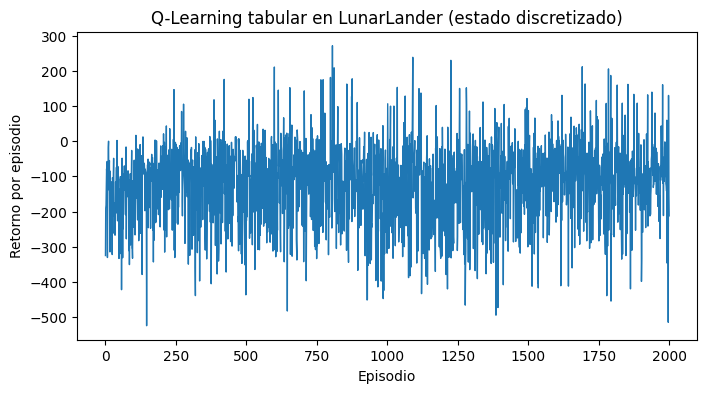

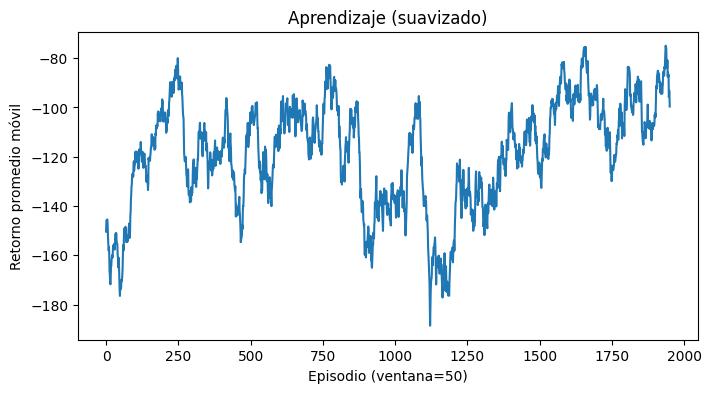

In [ ]:
# Entrenamiento (ajusta episodios si quieres explorar más)
learner, rewards = train_q_learning(episodes=2000, max_steps=1000)

# Curva de retorno por episodio
plt.figure(figsize=(8,4))
plt.plot(rewards, linewidth=1)
plt.xlabel("Episodio")
plt.ylabel("Retorno por episodio")
plt.title("Q-Learning tabular en LunarLander (estado discretizado)")
plt.show()

# Promedio móvil para suavizar (ventana=50)
win = 50
if len(rewards) >= win:
    mov_avg = np.convolve(rewards, np.ones(win)/win, mode="valid")
    plt.figure(figsize=(8,4))
    plt.plot(mov_avg)
    plt.xlabel(f"Episodio (ventana={win})")
    plt.ylabel("Retorno promedio móvil")
    plt.title("Aprendizaje (suavizado)")
    plt.show()


In [ ]:
def evaluate_agent(learner, episodes=1, outdir="./videos_qlearn"):
    """
    Ejecuta la política greedy (argmax_a Q[s,a]) y guarda video(s) .mp4.
    Si el estado s no está en Q (nunca visitado), elige acción aleatoria de respaldo.
    """
    if os.path.exists(outdir):
        shutil.rmtree(outdir)

    env = RecordVideo(
        gym.make(ENV_ID, render_mode="rgb_array"),
        video_folder=outdir,
        episode_trigger=lambda ep: True
    )

    for ep in range(episodes):
        obs, _ = env.reset(seed=999 + ep)
        s = discretize(obs)
        done = False
        while not done:
            a = int(np.argmax(learner.Q[s])) if s in learner.Q else env.action_space.sample()
            obs, r, term, trunc, _ = env.step(a)
            s = discretize(obs)
            done = term or trunc

    env.close()

    print(f"Videos guardados en: {outdir}")
    mp4s = [f for f in os.listdir(outdir) if f.endswith(".mp4")]
    mp4s.sort()
    if mp4s:
        display(Video(os.path.join(outdir, mp4s[0])))


In [ ]:
evaluate_agent(learner, episodes=10, outdir="./videos_qlearn")


Videos guardados en: ./videos_qlearn
